# Plost histograms of activations

load data and plot

In [3]:
import pickle
import numpy as np
out_file = '../attentional_gain_activations/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4.pkl'

with open(out_file, 'rb') as f:
    acts = pickle.load(f)

In [12]:
acts

{'cue_acts': {'attn_block_in': array([-0.2837 , -0.2395 , -0.11304, ..., -0.09076, -0.3694 , -0.4858 ],
        dtype=float16),
  'attn_block0': array([0.09436, 0.1685 , 0.199  , ..., 0.2312 , 0.2347 , 0.1696 ],
        dtype=float16),
  'attn_block1': array([0.4282, 0.679 , 0.592 , ..., 0.2808, 0.4841, 0.8267], dtype=float16),
  'attn_block2': array([0.2084  , 0.417   , 0.2106  , ..., 0.0053  , 0.01822 , 0.001099],
        dtype=float16),
  'attn_block3': array([0.842 , 0.26  , 0.0523, ..., 1.984 , 2.727 , 5.266 ], dtype=float16),
  'attn_block4': array([0.     , 0.7354 , 3.488  , ..., 0.10913, 0.     , 0.     ],
        dtype=float16),
  'attn_block5': array([0.1692, 0.5557, 1.3   , ..., 9.6   , 1.63  , 0.    ], dtype=float16),
  'attn_block6': array([0., 0., 0., ..., 0., 0., 0.], dtype=float16)},
 'gain_acts': {'attn_block_in': array([0.3767, 0.393 , 0.4414, ..., 0.4502, 0.3457, 0.3054], dtype=float16),
  'attn_block0': array([1., 1., 1., ..., 1., 1., 1.], dtype=float16),
  'attn_bl

In [4]:
import pandas as pd
model_dfs = []
for layer in acts['cue_acts'].keys():
    layer_dict = {'cue_acts': acts['cue_acts'][layer],
                'gain_acts': acts['gain_acts'][layer],
                'layer':[f"{layer}"] * len(acts['cue_acts'][layer])}
#                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
    layer_df = pd.DataFrame.from_dict(layer_dict)
    model_dfs.append(layer_df)
model_df = pd.concat(model_dfs)


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter


In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    

In [7]:
def get_sigmoid(acts, layer, n_bins):
    gain_fn_params = acts['gain_params'][layer]
    cue_acts = acts['cue_acts'][layer]
    
    x_for_fn = np.linspace(cue_acts.min(), cue_acts.max(), n_bins)
    bias = gain_fn_params['bias']
    slope = gain_fn_params['slope']
    threshold = gain_fn_params['threshold']
    
    return attn_gain(x_for_fn, bias, slope, threshold).T, x_for_fn
    
        

{0: (0.96739773, 0.77451297, 0.65057302), 1: (0.29977678, 0.11356089, 0.29254823)}


/tmp/ipykernel_11094/275922424.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[ix,0].set_xticklabels(["min", "max"])
/tmp/ipykernel_11094/275922424.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[ix,0].set_xticklabels(["min", "max"])


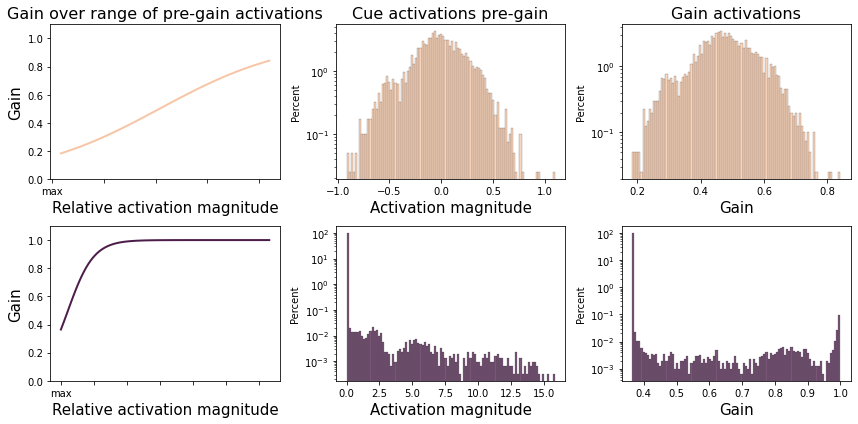

In [18]:

# Look at inputs to gain functions 
fig, axs = plt.subplots(2,3, figsize=(12,6))
# axs = axs.ravel()

n_hist_bins = 100
pad = 8

c_palette = sns.color_palette("rocket_r", 9, as_cmap=False)
layer_palette = { 0: c_palette[0],
                 1: c_palette[7]
}
print(layer_palette)

layer_names = model_df.layer.unique()
layer_names_sp = [layer_names[0], layer_names[-1]]

# x_for_sigmoid = np.arange(n_hist_bins)

for ix, layer in enumerate(layer_names_sp):

    # Plot filters 
    
    gain_filter, input_act_vals = get_sigmoid(acts, layer, n_hist_bins)    
    axs[ix,0].plot(input_act_vals, gain_filter, linewidth=2, c=layer_palette[ix]) # linewidth=4,

    # plot hist of cue activations    
    sns.histplot(data=model_df[model_df.layer == layer], x='cue_acts',
             stat='percent',  log_scale=(False, True), edgecolor='0.1',
#              hue='model', hue_order=hue_order, palette=model_palette,
             color=layer_palette[ix], bins=n_hist_bins, ax=axs[ix,1])

    # plot hist of gains
    sns.histplot(data=model_df[model_df.layer == layer], x='gain_acts',
                 stat='percent',  log_scale=(False, True), edgecolor='0.1',
#                  hue='model', hue_order=hue_order, palette=model_palette,
                 color=layer_palette[ix], bins=n_hist_bins, ax=axs[ix,2])
    
#     axs[ix,0].annotate(layer, xy=(0, 0.5), xytext=(-axs[ix,0].yaxis.labelpad - pad, 0),
#                 xycoords=axs[ix,0].yaxis.label, textcoords='offset points',
#                 size='large', ha='right', va='center')
    
    
    axs[ix,0].set_ylabel("Gain", fontsize=15)
    axs[ix,0].set_xlabel("Relative activation magnitude", fontsize=15)
    axs[ix,0].set_xticklabels(["min", "max"])

    axs[ix,0].set_ylim(0,1.1)


    axs[ix,1].set_xlabel("Activation magnitude", fontsize=15)
    axs[ix,2].set_xlabel("Gain", fontsize=15)
    
axs[0,0].set_title("Gain over range of pre-gain activations", fontsize=16)
axs[0,1].set_title("Cue activations pre-gain", fontsize=16)
axs[0,2].set_title("Gain activations", fontsize=16)



# axs[0,0].legend(loc="upper right", bbox_to_anchor=(4.25, 1))
# axs[0,1].get_legend().remove()
# axs[0,2].get_legend().remove()

# for ax in axs[1:,1:].ravel():
#     ax.get_legend().remove()
        

# plt.suptitle('LayerNorm after Cochleagram - Constrained Slope', y=1)


plt.tight_layout()

In [9]:
# len(attn_output_dict), len(cnn_outputs)

In [10]:
#  sns.histplot(input_mixtures.flatten().astype('float32'), stat='percent', log_scale=(False, True),
#                  bins=n_hist_bins, #binrange=(layer_activations.min(), layer_activations.max()),
#                  color='blue', alpha=.5, edgecolor='0.1')

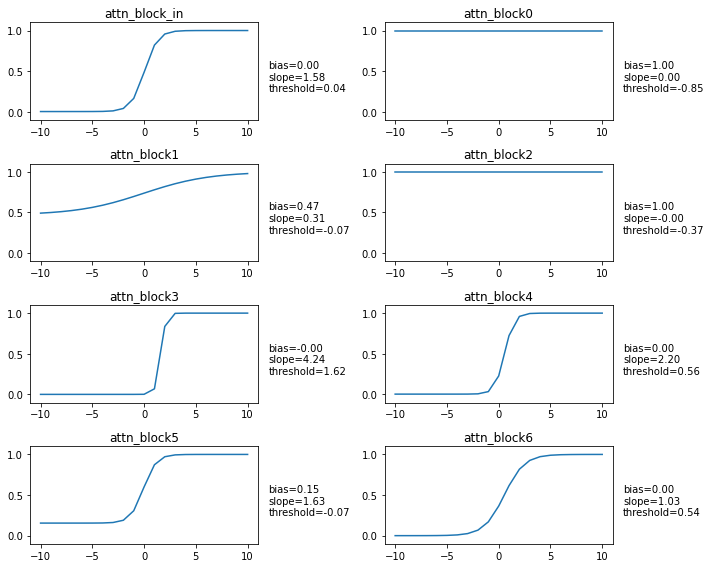

In [15]:
fig, axs = plt.subplots(4,2, figsize=(10,8))


axs = axs.ravel()
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-10,11)

attn_modules = acts['gain_params']
for i, name in enumerate(acts['gain_params'].keys()):
    bias =  attn_modules[name]['bias']
    slope =  attn_modules[name]['slope']
    threshold =  attn_modules[name]['threshold']
    gain = attn_gain(x ,
                bias,
                 slope,
                 threshold)
    axs[i].plot(x, gain)
    axs[i].text(12, 0.25, f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(name)
    axs[i].set_ylim(-0.1,1.1)

#     axs[i].set_xlim(-1,1)

    
    
plt.tight_layout()

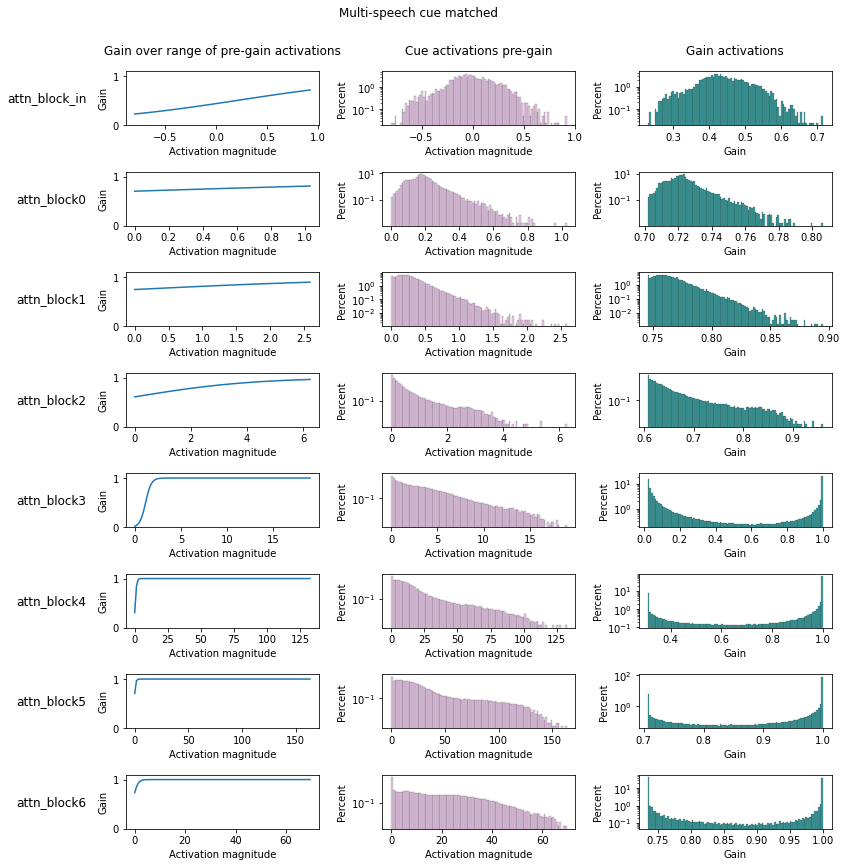

In [31]:

# Look at inputs to gain functions 
fig, axs = plt.subplots(8,3, figsize=(12,12))
# axs = axs.ravel()

n_hist_bins = 100
pad = 8


for ix, name in enumerate(attn_modules.keys()):
    layer_activations = cue_act_dict[name] # input to gain
    layer_outputs = attn_gain_outputs[name] # output from gain
    
    
    
    x_for_sig = np.linspace(layer_activations.min(), layer_activations.max(), n_hist_bins)
    gain = attn_gain(x_for_sig,
                     attn_modules[name].bias.item(),
                     attn_modules[name].slope.item(),
                     attn_modules[name].threshold.item())

    axs[ix,0].plot(x_for_sig, gain)

    # plot hist of activations
    sns.histplot(layer_activations, stat='percent', log_scale=(False, True),
                 bins=n_hist_bins, #binrange=(layer_activations.min(), layer_activations.max()),
                 ax=axs[ix,1], color='plum', alpha=.5, edgecolor='0.1')
    
    # plot functional range of sigmoid
    # get params 
    sns.histplot(layer_outputs, stat='percent',  log_scale=(False, True),
                 bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
                 ax=axs[ix,2], color='teal', edgecolor='0.1')


    
    axs[ix,0].annotate(name, xy=(0, 0.5), xytext=(-axs[ix,0].yaxis.labelpad - pad, 0),
                xycoords=axs[ix,0].yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
    
    axs[ix,0].set_ylabel("Gain")
    
    axs[ix,0].set_xlabel("Activation magnitude")
    axs[ix,1].set_xlabel("Activation magnitude")
    axs[ix,2].set_xlabel("Gain")
    
    axs[ix,0].ticklabel_format(useOffset=False)
#     axs[ix,1].ticklabel_format(useOffset=False)
#     axs[ix,2].ticklabel_format(useOffset=False)

    
axs[0,0].set_title("Gain over range of pre-gain activations", y=1.2)
axs[0,1].set_title("Cue activations pre-gain", y=1.2)
axs[0,2].set_title("Gain activations", y=1.2)


for ax in axs[:,0].ravel():
    ax.set_ylim(0,1.1)
    
# # for ax in axs[:,0].ravel():
# axs[0,2].xaxis.set_major_formatter(FormatStrFormatter('%.6f'))
# axs[5,2].xaxis.set_major_formatter(FormatStrFormatter('%.7f'))

plt.suptitle('Multi-speech cue matched', y=1)


plt.tight_layout()

In [60]:
!nvidia-smi

Fri Sep  9 18:52:54 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.67       Driver Version: 460.67       CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  GeForce GTX 108...  On   | 00000000:82:00.0 Off |                  N/A |
| 25%   35C    P8    10W / 250W |   3976MiB / 11178MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------